In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.ori_finder import cumulative_skew, predict_oric, find_dnaa_boxes
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np

record = next(SeqIO.parse('../data/sample/e_profundum_genome.fasta', 'fasta'))
genome = str(record.seq)
print(f'Organism: {record.description}')
print(f'Genome length: {len(genome):,} bp')
print(f'GC content: {(genome.count("G") + genome.count("C")) / len(genome) * 100:.1f}%')

Organism: NC_006370.1 Photobacterium profundum SS9 chromosome 1, complete sequence
Genome length: 4,085,304 bp
GC content: 42.0%


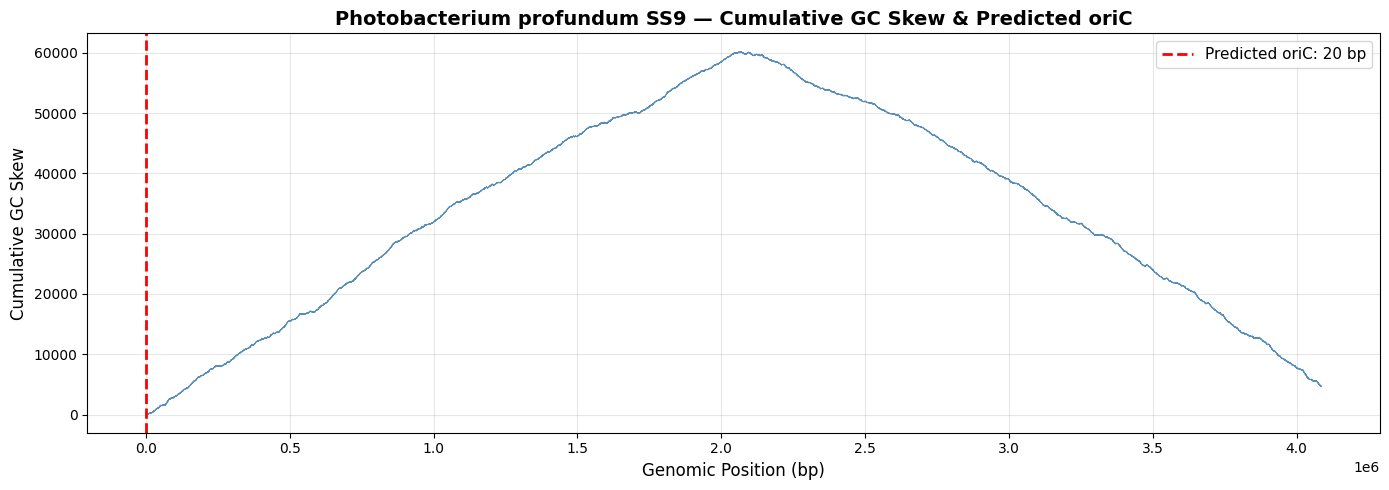

Predicted oriC position: 20 bp


In [2]:
# Calculate and plot cumulative GC skew
skew = cumulative_skew(genome)
oric = predict_oric(genome)

plt.figure(figsize=(14, 5))
plt.plot(skew, color='steelblue', linewidth=0.8, alpha=0.9)
plt.axvline(oric, color='red', linestyle='--', linewidth=2,
            label=f'Predicted oriC: {oric:,} bp')
plt.xlabel('Genomic Position (bp)', fontsize=12)
plt.ylabel('Cumulative GC Skew', fontsize=12)
plt.title('Photobacterium profundum SS9 — Cumulative GC Skew & Predicted oriC',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/results/oric_gcskew_notebook.png', dpi=150)
plt.show()
print(f'Predicted oriC position: {oric:,} bp')

In [3]:
# Find DnaA box candidates near oriC
dnaa_boxes = find_dnaa_boxes(genome, oric)

print(f'Top candidate DnaA box sequences near oriC ({oric:,} bp):')
print('-' * 45)
for kmer, count in dnaa_boxes[:5]:
    print(f'  {kmer}  →  count: {count}')

print()
print('E. coli reference DnaA box: TTATCCACA')
print()
print('Biological interpretation:')
print('These are the most frequent 9-mers near the predicted oriC.')
print('The DnaA protein binds these sequences to initiate replication.')

Top candidate DnaA box sequences near oriC (20 bp):
---------------------------------------------
  CTAATTTGA  →  count: 2
  CAAATTAGC  →  count: 2
  ACATCGATA  →  count: 2
  CAAAATAGC  →  count: 1
  AAAATAGCT  →  count: 1

E. coli reference DnaA box: TTATCCACA

Biological interpretation:
These are the most frequent 9-mers near the predicted oriC.
The DnaA protein binds these sequences to initiate replication.


In [4]:
# Summary
print('=== NOTEBOOK 2 SUMMARY ===')
print()
print(f'Organism: Photobacterium profundum SS9')
print(f'Genome size: {len(genome):,} bp')
print(f'GC content: 42.0%')
print(f'Predicted oriC: {oric:,} bp')
print()
print('Method: Cumulative GC skew minimum')
print('The minimum point of cumulative GC skew predicts')
print('where DNA replication begins in this deep-sea bacteria.')

=== NOTEBOOK 2 SUMMARY ===

Organism: Photobacterium profundum SS9
Genome size: 4,085,304 bp
GC content: 42.0%
Predicted oriC: 20 bp

Method: Cumulative GC skew minimum
The minimum point of cumulative GC skew predicts
where DNA replication begins in this deep-sea bacteria.
